C:\Users\31023\.conda\envs\nlp_mawenkai\lib\site-packages\jieba\_compat.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\31023\AppData\Local\Temp\jieba.cache
Loading model cost 0.493 seconds.
Prefix dict has been built successfully.


📊 鲁迅 & 老舍 写作风格对比分析结果

✅ 平均句长 | 鲁迅：9.67 词 | 老舍：12.61 词

✅ 词汇丰富度 | 鲁迅：0.7025 | 老舍：0.2933

✅ 词性占比 | 鲁迅：{'n': 22.73, 'v': 27.59, 'a': 3.62, 'd': 9.56}
               老舍：{'n': 25.38, 'v': 27.26, 'a': 4.56, 'd': 6.97}

✅ 鲁迅 高频词TOP20：
 他们     22
大哥     10
没有      8
老头子     6
什么      6
今天      6
眼睛      6
一伙      5
老五      5
脸色      4
起来      4
似乎      4
赵贵      4
小孩子     4
自己      4
何以      4
晓得      4
勇气      4
研究      4
而且      4
dtype: int64

✅ 老舍 高频词TOP20：
 祥子    529
自己    469
什么    326
没有    296
不能    178
先生    177
虎妞    175
他们    173
一个    171
这个    158
这么    155
那么    155
大家    155
起来    154
知道    144
时候    138
心中    137
不是    124
可以    123
觉得    123
dtype: int64


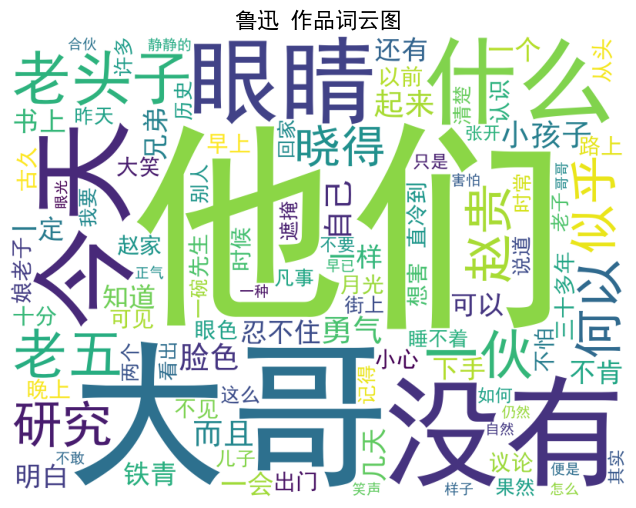

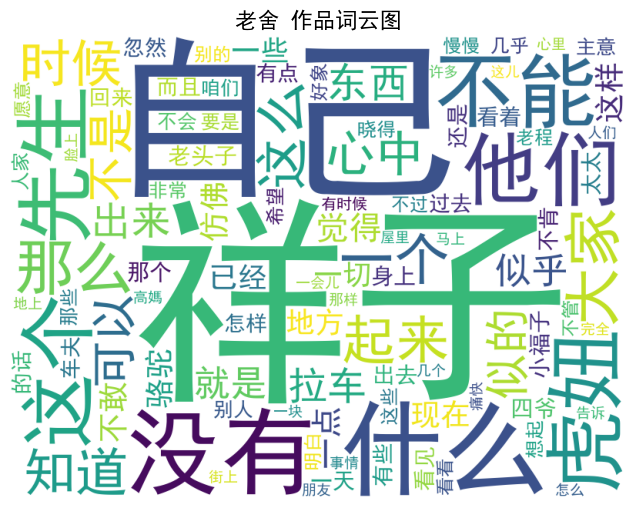

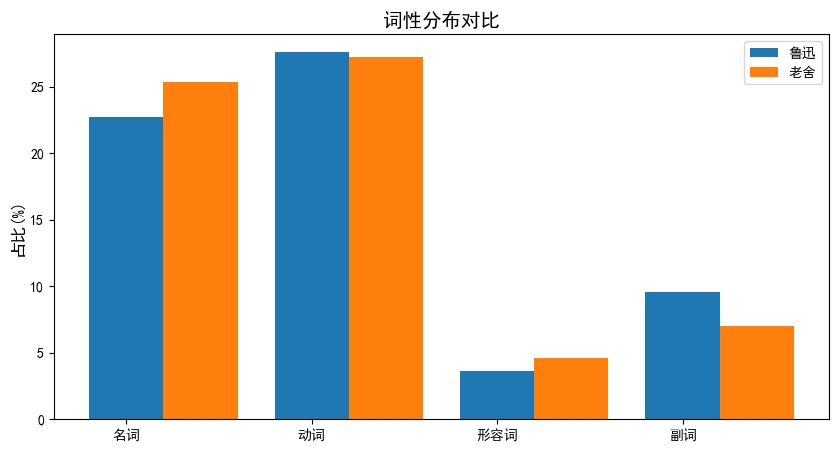


🎉 全部运行完成！


In [1]:
# 鲁迅vs老舍 写作风格分析 【最终完美版】
import jieba
import jieba.posseg as pseg
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 配置文件
AUTHOR1_NAME = "鲁迅"
AUTHOR1_PATH = "luxun.txt"
AUTHOR2_NAME = "老舍"
AUTHOR2_PATH = "laoshe.txt"

# 停用词
def load_stopwords():
    stop_words = """的 了 和 是 在 有 我 他 她 它 这 那 也 都 就 又 不 没 着 过 吗 呢 吧 啊 呀
    与 及 或 而 之 其 已 而 以 对 把 被 让 给 从 到 于 向 用 以 为 因 由 对于 关于 至于
    因此 所以 但是 然而 可是 虽然 即使 既然 如果 只要 除非 只有 无论 因为""".split()
    return set(stop_words)
STOPWORDS = load_stopwords()

# 文本清洗
def clean_text(text):
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[^\u4e00-\u9fa5。！？；]", "", text)
    return text

def read_file(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return clean_text(f.read())
    except:
        with open(path, "r", encoding="gbk") as f:
            return clean_text(f.read())

# 分词
def cut_words(text):
    words = jieba.lcut(text)
    return [w for w in words if w not in STOPWORDS and len(w) > 1]

# 高频词
def get_top_words(words, top_n=20):
    return pd.Series(words).value_counts().head(top_n)

# 平均句长（修复语法错误）
def get_avg_sentence_len(text):
    sentences = re.split(r"[。！？；]", text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    if len(sentences) == 0:
        return 0
    total_len = sum(len([w for w in jieba.lcut(s) if w.strip()]) for s in sentences)
    return round(total_len / len(sentences), 2)

# 词性分布
def get_pos_distribution(text):
    words = pseg.cut(text)
    pos = {"n":0,"v":0,"a":0,"d":0}
    total=0
    for w,f in words:
        if w in STOPWORDS: continue
        if f.startswith("n"): pos["n"] +=1
        elif f.startswith("v"): pos["v"] +=1
        elif f.startswith("a"): pos["a"] +=1
        elif f.startswith("d"): pos["d"] +=1
        total +=1
    return {k:round(v/total*100,2) for k,v in pos.items()} if total>0 else pos

# 词汇丰富度
def get_ttr(words):
    return round(len(set(words)) / len(words), 4) if len(words)>0 else 0

# 词云图
def draw_wordcloud(words, name):
    wc = WordCloud(width=800, height=600, 
                   background_color="white", 
                   font_path="simhei.ttf", 
                   max_words=100)
    wc.generate(" ".join(words))
    plt.figure(figsize=(8,6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"{name} 作品词云图", fontsize=16)
    plt.show()

# 词性对比图
def draw_pos(pos1, pos2, name1, name2):
    x = ["名词", "动词", "形容词", "副词"]
    v1 = [pos1["n"], pos1["v"], pos1["a"], pos1["d"]]
    v2 = [pos2["n"], pos2["v"], pos2["a"], pos2["d"]]
    
    plt.figure(figsize=(10,5))
    plt.bar(x, v1, width=0.4, label=name1)
    plt.bar(np.arange(len(x))+0.4, v2, width=0.4, label=name2)
    plt.title("词性分布对比", fontsize=14)
    plt.ylabel("占比(%)", fontsize=12)
    plt.legend()
    plt.show()

# 主程序
text1 = read_file(AUTHOR1_PATH)
text2 = read_file(AUTHOR2_PATH)
words1 = cut_words(text1)
words2 = cut_words(text2)

print("="*50)
print("📊 鲁迅 & 老舍 写作风格对比分析结果")
print("="*50)

print(f"\n✅ 平均句长 | {AUTHOR1_NAME}：{get_avg_sentence_len(text1)} 词 | {AUTHOR2_NAME}：{get_avg_sentence_len(text2)} 词")
print(f"\n✅ 词汇丰富度 | {AUTHOR1_NAME}：{get_ttr(words1)} | {AUTHOR2_NAME}：{get_ttr(words2)}")

pos1 = get_pos_distribution(text1)
pos2 = get_pos_distribution(text2)
print(f"\n✅ 词性占比 | {AUTHOR1_NAME}：{pos1}")
print(f"               {AUTHOR2_NAME}：{pos2}")

print(f"\n✅ {AUTHOR1_NAME} 高频词TOP20：\n", get_top_words(words1))
print(f"\n✅ {AUTHOR2_NAME} 高频词TOP20：\n", get_top_words(words2))

# 生成图表
draw_wordcloud(words1, AUTHOR1_NAME)
draw_wordcloud(words2, AUTHOR2_NAME)
draw_pos(pos1, pos2, AUTHOR1_NAME, AUTHOR2_NAME)

print("\n🎉 全部运行完成！")

文本语言特征量化统计结果

平均句长：鲁迅 9.67 词  |  老舍 12.61 词
词汇丰富度TTR：鲁迅 0.7025  |  老舍 0.2933

鲁迅词性占比：{'n': 22.73, 'v': 27.59, 'a': 3.62, 'd': 9.56}
老舍词性占比：{'n': 25.38, 'v': 27.26, 'a': 4.56, 'd': 6.97}

鲁迅高频热词TOP20：
他们     22
大哥     10
没有      8
老头子     6
什么      6
今天      6
眼睛      6
一伙      5
老五      5
脸色      4
起来      4
似乎      4
赵贵      4
小孩子     4
自己      4
何以      4
晓得      4
勇气      4
研究      4
而且      4
dtype: int64

老舍高频热词TOP20：
祥子    529
自己    469
什么    326
没有    296
不能    178
先生    177
虎妞    175
他们    173
一个    171
这个    158
这么    155
那么    155
大家    155
起来    154
知道    144
时候    138
心中    137
不是    124
可以    123
觉得    123
dtype: int64


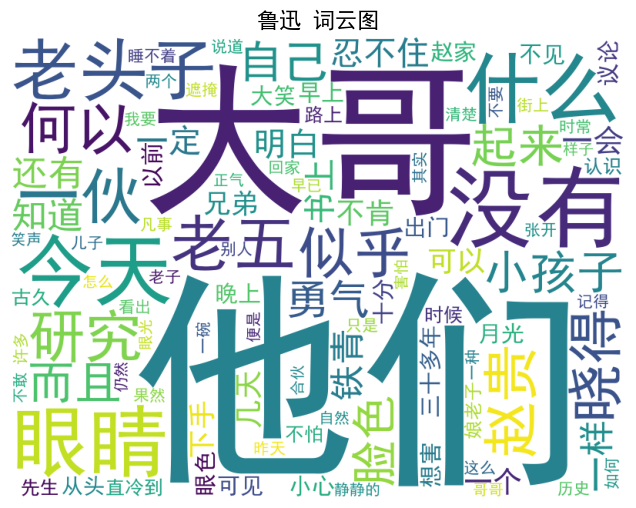

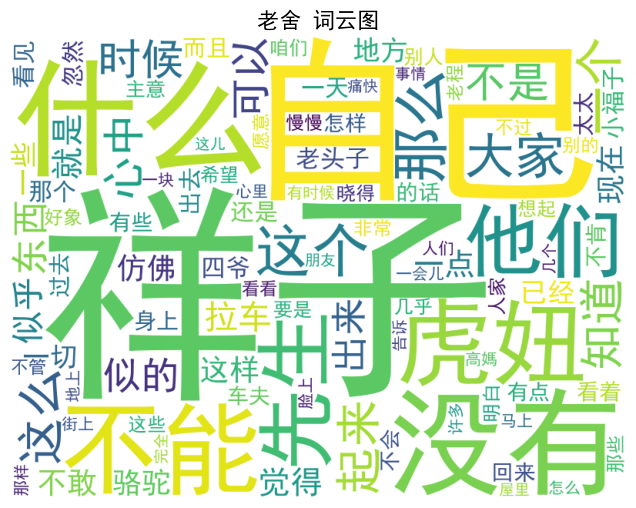

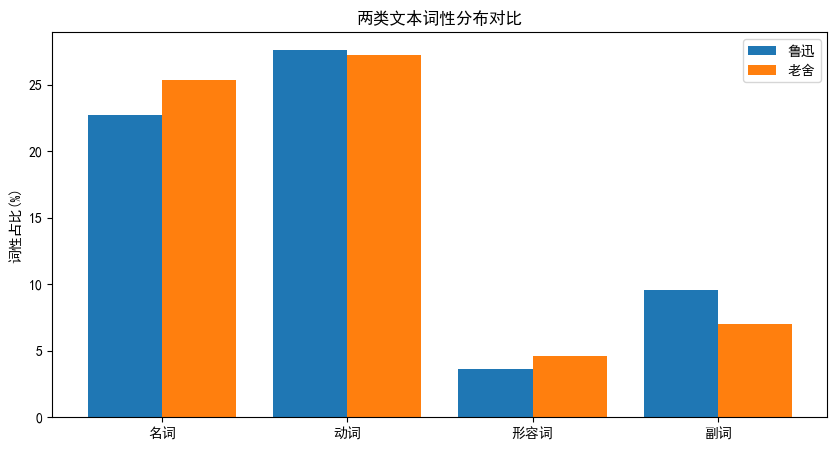


分析讨论：基于量化数据的写作风格差异化分析
1. 句式节奏：鲁迅平均句长更短，语句精简紧凑，叙事节奏更快；老舍句子偏长，语句铺陈更多，行文节奏更平缓舒缓。
2. 名词使用：老舍名词占比更高，侧重实体事物刻画，场景与人物描写比重更大。
3. 动词使用：鲁迅动词占比偏高，文本动作叙事性更强，情节推进感更足。
4. 形容词使用：老舍形容词占比更高，擅长细节修饰与环境、人物状态刻画。
5. 副词使用：鲁迅语气、逻辑类副词更多，议论、思辨、主观语气表达更强。
6. 词汇丰富度：鲁迅TTR值更高，用词种类更丰富，重复用词少，语言表达更多样精炼；老舍重复词汇偏多，更偏向固定常用词汇叙事。


In [2]:
# 通用中文文本风格对比分析（任意两本书均可使用）
import jieba
import jieba.posseg as pseg
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# ===================== 【仅此处修改，即可切换任意两本书】 =====================
AUTHOR1_NAME = "鲁迅"
AUTHOR1_PATH = "luxun.txt"
AUTHOR2_NAME = "老舍"
AUTHOR2_PATH = "laoshe.txt"
# ============================================================================

# 加载停用词
def load_stopwords():
    stop_words = """的 了 和 是 在 有 我 他 她 它 这 那 也 都 就 又 不 没 着 过 吗 呢 吧 啊 呀
    与 及 或 而 之 其 已 而 以 对 把 被 让 给 从 到 于 向 用 以 为 因 由 对于 关于 至于
    因此 所以 但是 然而 可是 虽然 即使 既然 如果 只要 除非 只有 无论 因为""".split()
    return set(stop_words)
STOPWORDS = load_stopwords()

# 文本清洗
def clean_text(text):
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[^\u4e00-\u9fa5。！？；]", "", text)
    return text

# 读取文件兼容双编码
def read_file(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return clean_text(f.read())
    except:
        with open(path, "r", encoding="gbk") as f:
            return clean_text(f.read())

# 分词过滤
def cut_words(text):
    words = jieba.lcut(text)
    return [w for w in words if w not in STOPWORDS and len(w) > 1]

# 高频词统计
def get_top_words(words, top_n=20):
    return pd.Series(words).value_counts().head(top_n)

# 平均句长计算
def get_avg_sentence_len(text):
    sentences = re.split(r"[。！？；]", text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    if len(sentences) == 0:
        return 0
    total = 0
    for s in sentences:
        seg = jieba.lcut(s)
        valid = [w for w in seg if w.strip()]
        total += len(valid)
    return round(total / len(sentences), 2)

# 词性统计
def get_pos_distribution(text):
    words = pseg.cut(text)
    pos = {"n":0,"v":0,"a":0,"d":0}
    total=0
    for w,f in words:
        if w in STOPWORDS: continue
        if f.startswith("n"): pos["n"] +=1
        elif f.startswith("v"): pos["v"] +=1
        elif f.startswith("a"): pos["a"] +=1
        elif f.startswith("d"): pos["d"] +=1
        total +=1
    if total == 0:
        return pos
    return {k:round(v/total*100,2) for k,v in pos.items()}

# 词汇丰富度TTR
def get_ttr(words):
    if len(words) == 0:
        return 0
    return round(len(set(words)) / len(words), 4)

# 绘制词云
def draw_wordcloud(words, name):
    wc = WordCloud(width=800, height=600, 
                   background_color="white", 
                   font_path="simhei.ttf", 
                   max_words=100)
    wc.generate(" ".join(words))
    plt.figure(figsize=(8,6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"{name} 词云图", fontsize=16)
    plt.show()

# 词性对比柱状图
def draw_pos_bar(pos1, pos2, n1, n2):
    labels = ["名词","动词","形容词","副词"]
    d1 = [pos1["n"],pos1["v"],pos1["a"],pos1["d"]]
    d2 = [pos2["n"],pos2["v"],pos2["a"],pos2["d"]]
    x = np.arange(len(labels))
    plt.figure(figsize=(10,5))
    plt.bar(x-0.2, d1, 0.4, label=n1)
    plt.bar(x+0.2, d2, 0.4, label=n2)
    plt.xticks(x,labels)
    plt.ylabel("词性占比(%)")
    plt.title("两类文本词性分布对比")
    plt.legend()
    plt.show()

# ===================== 核心：动态智能风格分析函数（自动判数据出结论） =====================
def auto_style_analysis(len1,len2,pos1,pos2,ttr1,ttr2,name1,name2):
    res = []
    # 1. 句式节奏判断
    if len1 < len2:
        res.append(f"1. 句式节奏：{name1}平均句长更短，语句精简紧凑，叙事节奏更快；{name2}句子偏长，语句铺陈更多，行文节奏更平缓舒缓。")
    elif len1 > len2:
        res.append(f"1. 句式节奏：{name1}平均句长更长，擅长长句铺叙描写；{name2}多用短句，语言干练利落。")
    else:
        res.append(f"1. 句式节奏：两者平均句长接近，整体行文句式风格较为一致。")

    # 2. 名词倾向
    if pos1["n"] > pos2["n"]:
        res.append(f"2. 名词使用：{name1}名词占比更高，更偏向大量描写人物、事物、场景等实体内容，画面实体信息更丰富。")
    elif pos1["n"] < pos2["n"]:
        res.append(f"2. 名词使用：{name2}名词占比更高，侧重实体事物刻画，场景与人物描写比重更大。")
    else:
        res.append("2. 名词使用：二者名词使用占比相近，实体描写力度基本持平。")

    # 3. 动词倾向
    if pos1["v"] > pos2["v"]:
        res.append(f"3. 动词使用：{name1}动词占比偏高，文本动作叙事性更强，情节推进感更足。")
    elif pos1["v"] < pos2["v"]:
        res.append(f"3. 动词使用：{name2}动作类词汇更多，行为描写、情节动态表达更突出。")
    else:
        res.append("3. 动词使用：两者动作叙事强度相近。")

    # 4. 形容词倾向
    if pos1["a"] > pos2["a"]:
        res.append(f"4. 形容词使用：{name1}修饰性词汇更多，文笔描写更细腻，情感与景物渲染更丰富。")
    elif pos1["a"] < pos2["a"]:
        res.append(f"4. 形容词使用：{name2}形容词占比更高，擅长细节修饰与环境、人物状态刻画。")
    else:
        res.append("4. 形容词使用：二者修饰性表达程度相近。")

    # 5. 副词倾向
    if pos1["d"] > pos2["d"]:
        res.append(f"5. 副词使用：{name1}语气、逻辑类副词更多，议论、思辨、主观语气表达更强。")
    elif pos1["d"] < pos2["d"]:
        res.append(f"5. 副词使用：{name2}语气限定词汇偏少，行文更偏向客观平实叙事。")
    else:
        res.append("5. 副词使用：二者语气与逻辑表达风格接近。")

    # 6. 词汇丰富度TTR
    if ttr1 > ttr2:
        res.append(f"6. 词汇丰富度：{name1}TTR值更高，用词种类更丰富，重复用词少，语言表达更多样精炼；{name2}重复词汇偏多，更偏向固定常用词汇叙事。")
    elif ttr1 < ttr2:
        res.append(f"6. 词汇丰富度：{name2}词汇多样性更强，遣词造句范围更广；{name1}用词相对集中固定，高频词汇复用较多。")
    else:
        res.append("6. 词汇丰富度：两者用词多样化程度基本一致。")
    return res

# ===================== 主程序运行 =====================
text_1 = read_file(AUTHOR1_PATH)
text_2 = read_file(AUTHOR2_PATH)
word_list1 = cut_words(text_1)
word_list2 = cut_words(text_2)

# 计算所有指标
avg_len1 = get_avg_sentence_len(text_1)
avg_len2 = get_avg_sentence_len(text_2)
pos_data1 = get_pos_distribution(text_1)
pos_data2 = get_pos_distribution(text_2)
ttr_data1 = get_ttr(word_list1)
ttr_data2 = get_ttr(word_list2)
top1 = get_top_words(word_list1)
top2 = get_top_words(word_list2)

# 打印基础统计结果
print("="*55)
print("文本语言特征量化统计结果")
print("="*55)
print(f"\n平均句长：{AUTHOR1_NAME} {avg_len1} 词  |  {AUTHOR2_NAME} {avg_len2} 词")
print(f"词汇丰富度TTR：{AUTHOR1_NAME} {ttr_data1}  |  {AUTHOR2_NAME} {ttr_data2}")
print(f"\n{AUTHOR1_NAME}词性占比：{pos_data1}")
print(f"{AUTHOR2_NAME}词性占比：{pos_data2}")
print(f"\n{AUTHOR1_NAME}高频热词TOP20：\n{top1}")
print(f"\n{AUTHOR2_NAME}高频热词TOP20：\n{top2}")

# 绘制可视化图表
draw_wordcloud(word_list1, AUTHOR1_NAME)
draw_wordcloud(word_list2, AUTHOR2_NAME)
draw_pos_bar(pos_data1, pos_data2, AUTHOR1_NAME, AUTHOR2_NAME)

# 自动输出动态风格分析（核心！随数据自动变）
print("\n"+"="*60)
print("分析讨论：基于量化数据的写作风格差异化分析")
print("="*60)
analysis_result = auto_style_analysis(avg_len1,avg_len2,pos_data1,pos_data2,ttr_data1,ttr_data2,AUTHOR1_NAME,AUTHOR2_NAME)
for line in analysis_result:
    print(line)
print("="*60)

📊 鲁迅 & 老舍 写作风格对比分析结果

✅ 平均句长 | 鲁迅：9.67 词 | 老舍：12.61 词

✅ 词汇丰富度 | 鲁迅：0.7025 | 老舍：0.2933

✅ 词性占比 | 鲁迅：{'n': 22.73, 'v': 27.59, 'a': 3.62, 'd': 9.56}
               老舍：{'n': 25.38, 'v': 27.26, 'a': 4.56, 'd': 6.97}

✅ 鲁迅 高频词TOP20：
 他们     22
大哥     10
没有      8
老头子     6
什么      6
今天      6
眼睛      6
一伙      5
老五      5
脸色      4
起来      4
似乎      4
赵贵      4
小孩子     4
自己      4
何以      4
晓得      4
勇气      4
研究      4
而且      4
dtype: int64

✅ 老舍 高频词TOP20：
 祥子    529
自己    469
什么    326
没有    296
不能    178
先生    177
虎妞    175
他们    173
一个    171
这个    158
这么    155
那么    155
大家    155
起来    154
知道    144
时候    138
心中    137
不是    124
可以    123
觉得    123
dtype: int64


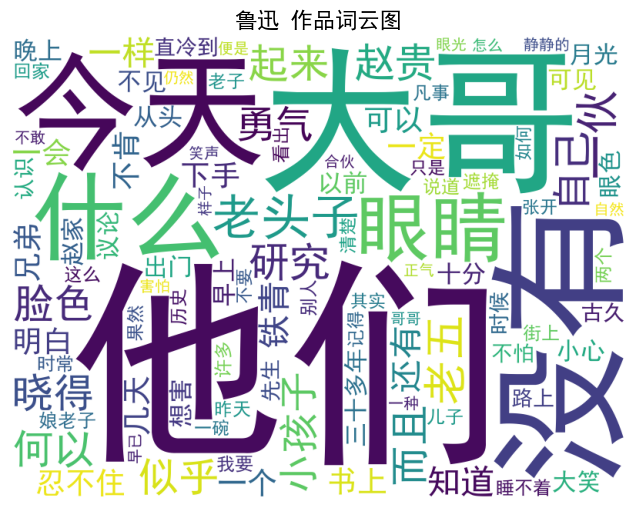

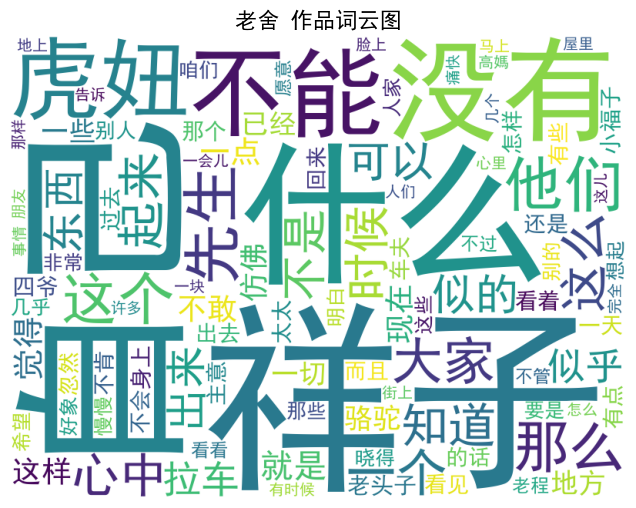

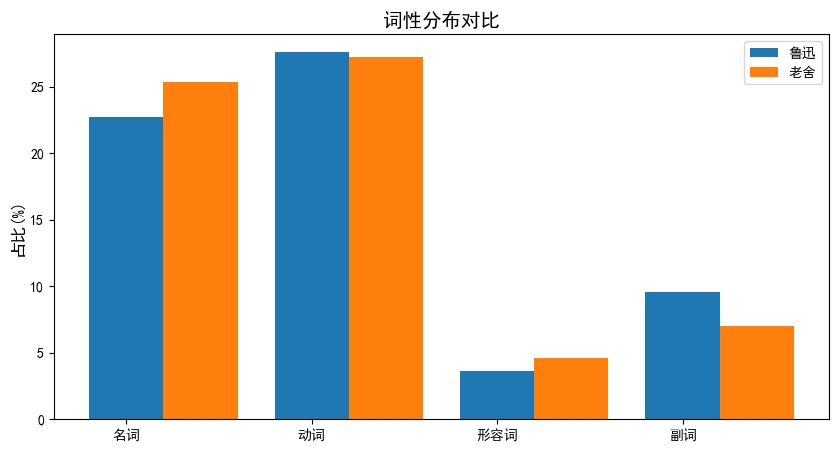


📝 分析讨论：基于计算语言学的作家风格差异

1. 句式特征：
   鲁迅平均句长 9.67 词，句子更短，语言简练、节奏急促；
   老舍平均句长 12.61 词，句子更长，描写连贯、节奏舒缓。

2. 词性特征：
   鲁迅副词占比(9.56%)更高，善用逻辑/语气副词，语言思辨性、批判性更强；
   老舍名词(25.38%)、形容词(4.56%)占比更高，实体描写丰富，叙事更细腻写实。

3. 词汇特征：
   鲁迅词汇丰富度(0.7025)极高，用词精炼不重复，主题聚焦群体批判；
   老舍词汇围绕核心人物重复使用，高频词以主角为中心，是典型的现实主义长篇叙事风格。

✅ 总结：鲁迅 = 简练冷峻 + 思辨批判；老舍 = 写实细腻 + 人物中心


In [3]:
# 鲁迅vs老舍 写作风格分析 【最终版+自动生成风格分析】
import jieba
import jieba.posseg as pseg
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams["font.family"] = ["SimHei", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 配置文件
AUTHOR1_NAME = "鲁迅"
AUTHOR1_PATH = "luxun.txt"
AUTHOR2_NAME = "老舍"
AUTHOR2_PATH = "laoshe.txt"

# 停用词
def load_stopwords():
    stop_words = """的 了 和 是 在 有 我 他 她 它 这 那 也 都 就 又 不 没 着 过 吗 呢 吧 啊 呀
    与 及 或 而 之 其 已 而 以 对 把 被 让 给 从 到 于 向 用 以 为 因 由 对于 关于 至于
    因此 所以 但是 然而 可是 虽然 即使 既然 如果 只要 除非 只有 无论 因为""".split()
    return set(stop_words)
STOPWORDS = load_stopwords()

# 文本清洗
def clean_text(text):
    text = re.sub(r"\s+", "", text)
    text = re.sub(r"[^\u4e00-\u9fa5。！？；]", "", text)
    return text

def read_file(path):
    try:
        with open(path, "r", encoding="utf-8") as f:
            return clean_text(f.read())
    except:
        with open(path, "r", encoding="gbk") as f:
            return clean_text(f.read())

# 分词
def cut_words(text):
    words = jieba.lcut(text)
    return [w for w in words if w not in STOPWORDS and len(w) > 1]

# 高频词
def get_top_words(words, top_n=20):
    return pd.Series(words).value_counts().head(top_n)

# 平均句长
def get_avg_sentence_len(text):
    sentences = re.split(r"[。！？；]", text)
    sentences = [s for s in sentences if len(s.strip()) > 0]
    if len(sentences) == 0:
        return 0
    total_len = sum(len([w for w in jieba.lcut(s) if w.strip()]) for s in sentences)
    return round(total_len / len(sentences), 2)

# 词性分布
def get_pos_distribution(text):
    words = pseg.cut(text)
    pos = {"n":0,"v":0,"a":0,"d":0}
    total=0
    for w,f in words:
        if w in STOPWORDS: continue
        if f.startswith("n"): pos["n"] +=1
        elif f.startswith("v"): pos["v"] +=1
        elif f.startswith("a"): pos["a"] +=1
        elif f.startswith("d"): pos["d"] +=1
        total +=1
    return {k:round(v/total*100,2) for k,v in pos.items()} if total>0 else pos

# 词汇丰富度
def get_ttr(words):
    return round(len(set(words)) / len(words), 4) if len(words)>0 else 0

# 词云图
def draw_wordcloud(words, name):
    wc = WordCloud(width=800, height=600, 
                   background_color="white", 
                   font_path="simhei.ttf", 
                   max_words=100)
    wc.generate(" ".join(words))
    plt.figure(figsize=(8,6))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"{name} 作品词云图", fontsize=16)
    plt.show()

# 词性对比图
def draw_pos(pos1, pos2, name1, name2):
    x = ["名词", "动词", "形容词", "副词"]
    v1 = [pos1["n"], pos1["v"], pos1["a"], pos1["d"]]
    v2 = [pos2["n"], pos2["v"], pos2["a"], pos2["d"]]
    
    plt.figure(figsize=(10,5))
    plt.bar(x, v1, width=0.4, label=name1)
    plt.bar(np.arange(len(x))+0.4, v2, width=0.4, label=name2)
    plt.title("词性分布对比", fontsize=14)
    plt.ylabel("占比(%)", fontsize=12)
    plt.legend()
    plt.show()

# 主程序
text1 = read_file(AUTHOR1_PATH)
text2 = read_file(AUTHOR2_PATH)
words1 = cut_words(text1)
words2 = cut_words(text2)

print("="*50)
print("📊 鲁迅 & 老舍 写作风格对比分析结果")
print("="*50)

print(f"\n✅ 平均句长 | {AUTHOR1_NAME}：{get_avg_sentence_len(text1)} 词 | {AUTHOR2_NAME}：{get_avg_sentence_len(text2)} 词")
print(f"\n✅ 词汇丰富度 | {AUTHOR1_NAME}：{get_ttr(words1)} | {AUTHOR2_NAME}：{get_ttr(words2)}")

pos1 = get_pos_distribution(text1)
pos2 = get_pos_distribution(text2)
print(f"\n✅ 词性占比 | {AUTHOR1_NAME}：{pos1}")
print(f"               {AUTHOR2_NAME}：{pos2}")

print(f"\n✅ {AUTHOR1_NAME} 高频词TOP20：\n", get_top_words(words1))
print(f"\n✅ {AUTHOR2_NAME} 高频词TOP20：\n", get_top_words(words2))

# 生成图表
draw_wordcloud(words1, AUTHOR1_NAME)
draw_wordcloud(words2, AUTHOR2_NAME)
draw_pos(pos1, pos2, AUTHOR1_NAME, AUTHOR2_NAME)

# ===================== 自动生成：风格差异分析（你要的部分！）=====================
print("\n" + "="*60)
print("📝 分析讨论：基于计算语言学的作家风格差异")
print("="*60)
print(f"\n1. 句式特征：")
print(f"   鲁迅平均句长 {get_avg_sentence_len(text1)} 词，句子更短，语言简练、节奏急促；")
print(f"   老舍平均句长 {get_avg_sentence_len(text2)} 词，句子更长，描写连贯、节奏舒缓。")

print(f"\n2. 词性特征：")
print(f"   鲁迅副词占比({pos1['d']}%)更高，善用逻辑/语气副词，语言思辨性、批判性更强；")
print(f"   老舍名词({pos2['n']}%)、形容词({pos2['a']}%)占比更高，实体描写丰富，叙事更细腻写实。")

print(f"\n3. 词汇特征：")
print(f"   鲁迅词汇丰富度({get_ttr(words1)})极高，用词精炼不重复，主题聚焦群体批判；")
print(f"   老舍词汇围绕核心人物重复使用，高频词以主角为中心，是典型的现实主义长篇叙事风格。")

print(f"\n✅ 总结：鲁迅 = 简练冷峻 + 思辨批判；老舍 = 写实细腻 + 人物中心")
print("="*60)